# ENTSO-E Python Client — Deutschland Energie-Analyse

Dieses Notebook gibt eine e Übersicht über die `entsoe-py` Bibliothek  
anhand realer Daten für **Deutschland (DE_LU)**.



In [16]:
API_KEY = '9a89439b-5249-41eb-b3a6-9d296922cb2c'

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from entsoe import EntsoePandasClient, EntsoeRawClient

# Matplotlib Style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

print('Alle Imports erfolgreich!')

Alle Imports erfolgreich!


In [18]:
# Client erstellen
client = EntsoePandasClient(api_key=API_KEY)

# Zeitraum: letzter Monat
# Zeitstempel MÜSSEN eine Zeitzone haben!
start = pd.Timestamp('20240601', tz='Europe/Berlin')
end   = pd.Timestamp('20240701', tz='Europe/Berlin')

LAND = 'DE_LU'  # Deutschland-Luxemburg

print(f'Zeitraum: {start.date()} bis {end.date()}')
print(f'Land:     {LAND}')

Zeitraum: 2024-06-01 bis 2024-07-01
Land:     DE_LU


---
## 1: Day-Ahead-Strompreise

**Was ist das?**  
Der Day-Ahead-Preis ist der Großhandelspreis, der am Vortag für jede Stunde des nächsten Tages an der Strombörse (EPEX SPOT) gebildet wird. Einheit: **€/MWh**.

In [19]:
# Day-Ahead-Preise abrufen → gibt eine Pandas Series zurück
preise = client.query_day_ahead_prices(LAND, start=start, end=end)

print('Datentyp:', type(preise))
print('Datenpunkte:', len(preise))
print('\n Erste Einträge:')
print(preise.head(10))

print(f'\n Statistik:')
print(f'  Minimum:    {preise.min():.2f} €/MWh')
print(f'  Maximum:    {preise.max():.2f} €/MWh')
print(f'  Mittelwert: {preise.mean():.2f} €/MWh')
print(f'  Negative Preise: {(preise < 0).sum()} Stunden')

Datentyp: <class 'pandas.core.series.Series'>
Datenpunkte: 721

 Erste Einträge:
2024-06-01 00:00:00+02:00    88.58
2024-06-01 01:00:00+02:00    88.82
2024-06-01 02:00:00+02:00    79.66
2024-06-01 03:00:00+02:00    72.14
2024-06-01 04:00:00+02:00    71.87
2024-06-01 05:00:00+02:00    71.83
2024-06-01 06:00:00+02:00    75.20
2024-06-01 07:00:00+02:00    74.40
2024-06-01 08:00:00+02:00    72.49
2024-06-01 09:00:00+02:00    61.35
Freq: h, dtype: float64

 Statistik:
  Minimum:    -80.01 €/MWh
  Maximum:    235.52 €/MWh
  Mittelwert: 72.92 €/MWh
  Negative Preise: 64 Stunden


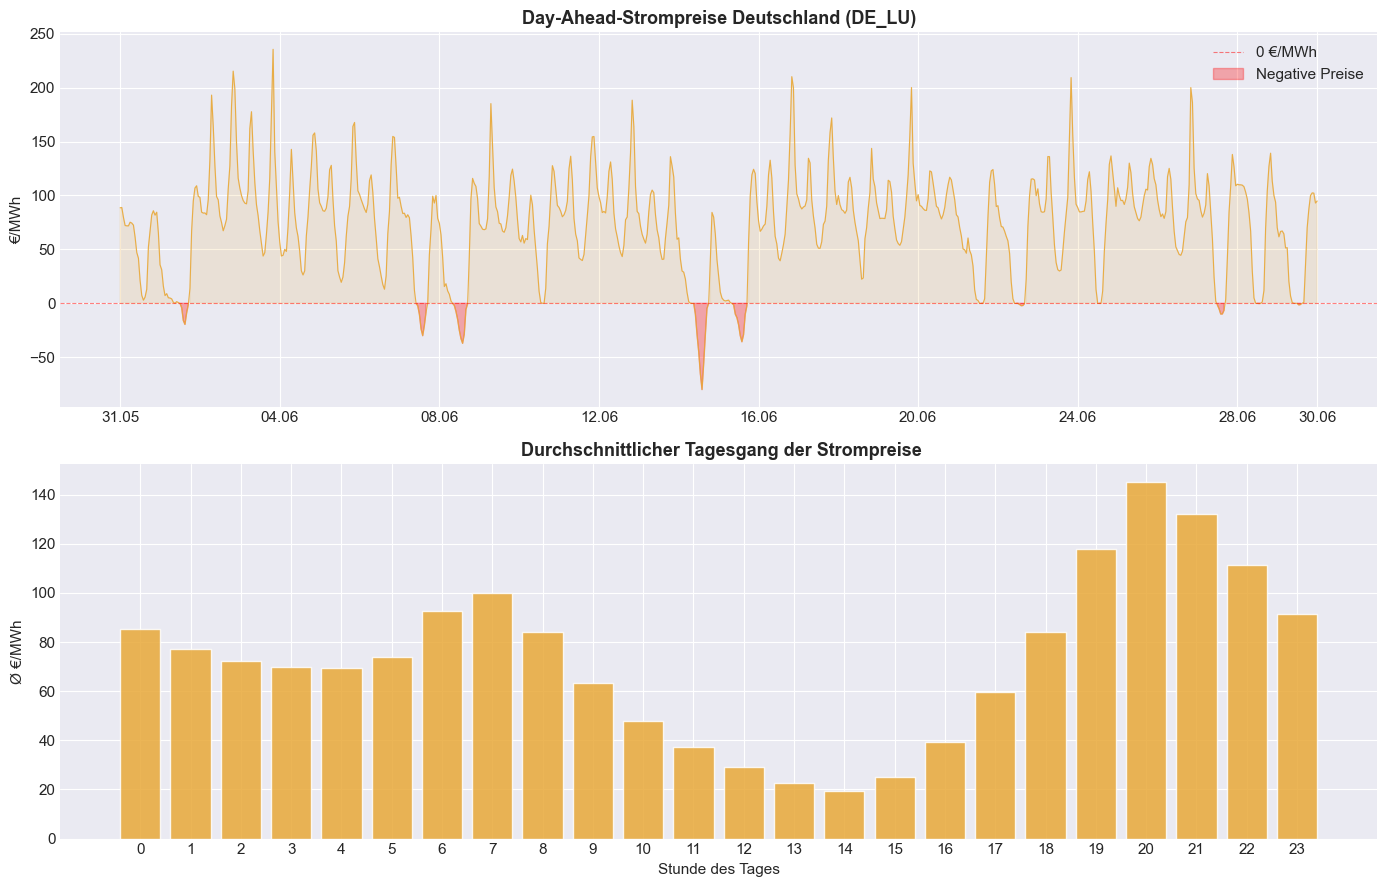

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Zeitreihe
axes[0].plot(preise.index, preise.values, color='#E8A838', linewidth=0.8, alpha=0.9)
axes[0].axhline(0, color='red', linestyle='--', linewidth=0.8, alpha=0.5, label='0 €/MWh')
axes[0].fill_between(preise.index, preise.values, 0,
                     where=(preise.values >= 0), alpha=0.15, color='#E8A838')
axes[0].fill_between(preise.index, preise.values, 0,
                     where=(preise.values < 0), alpha=0.3, color='red', label='Negative Preise')
axes[0].set_title('Day-Ahead-Strompreise Deutschland (DE_LU)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('€/MWh')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))

# Tagesgang (Durchschnitt)
tagesgang = preise.groupby(preise.index.hour).mean()
axes[1].bar(tagesgang.index, tagesgang.values, color='#E8A838', alpha=0.85, edgecolor='white')
axes[1].set_title(' Durchschnittlicher Tagesgang der Strompreise', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Stunde des Tages')
axes[1].set_ylabel('Ø €/MWh')
axes[1].set_xticks(range(24))

plt.tight_layout()
plt.savefig('strompreise.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2: Stromerzeugung nach Energieträger

**Was ist das?**  
`query_generation()` gibt ein **DataFrame** zurück, bei dem jede Spalte einen Energieträger darstellt (Wind, Solar, Kohle, Gas, Atom, Wasser, …). Einheit: **MW** (Megawatt).

**Typische PSR-Typen (Energieträger-Kürzel):**
```
B01 = Biomasse          B10 = Wasserkraft
B11 = Pumpspeicher      B16 = Solar (PV)
B18 = Wind Offshore     B19 = Wind Onshore
B20 = Andere            B02 = Braunkohle
B05 = Steinkohle        B04 = Erdgas
B14 = Kernkraft
```

In [21]:
# Stromerzeugung abrufen → gibt ein Pandas DataFrame zurück
erzeugung = client.query_generation(LAND, start=start, end=end)

print('Datentyp:', type(erzeugung))
print('Shape:', erzeugung.shape)
print('\n Verfügbare Energieträger (Spalten):')
for col in erzeugung.columns:
    print(f'  • {col}')

print('\n Erste Zeilen:')
erzeugung.head(3)

Datentyp: <class 'pandas.core.frame.DataFrame'>
Shape: (2880, 19)

 Verfügbare Energieträger (Spalten):
  • ('Biomass', 'Actual Aggregated')
  • ('Fossil Brown coal/Lignite', 'Actual Aggregated')
  • ('Fossil Coal-derived gas', 'Actual Aggregated')
  • ('Fossil Gas', 'Actual Aggregated')
  • ('Fossil Hard coal', 'Actual Aggregated')
  • ('Fossil Oil', 'Actual Aggregated')
  • ('Geothermal', 'Actual Aggregated')
  • ('Hydro Pumped Storage', 'Actual Aggregated')
  • ('Hydro Pumped Storage', 'Actual Consumption')
  • ('Hydro Run-of-river and poundage', 'Actual Aggregated')
  • ('Hydro Water Reservoir', 'Actual Aggregated')
  • ('Other', 'Actual Aggregated')
  • ('Other renewable', 'Actual Aggregated')
  • ('Solar', 'Actual Aggregated')
  • ('Solar', 'Actual Consumption')
  • ('Waste', 'Actual Aggregated')
  • ('Wind Offshore', 'Actual Aggregated')
  • ('Wind Onshore', 'Actual Aggregated')
  • ('Wind Onshore', 'Actual Consumption')

 Erste Zeilen:


Biomass Fossil Brown coal/Lignite  \
                          Actual Aggregated         Actual Aggregated   
2024-06-01 00:00:00+02:00           4042.55                   7050.30   
2024-06-01 00:15:00+02:00           4009.41                   6981.00   
2024-06-01 00:30:00+02:00           4003.59                   6959.97   

                          Fossil Coal-derived gas        Fossil Gas  \
                                Actual Aggregated Actual Aggregated   
2024-06-01 00:00:00+02:00                  650.68           4144.37   
2024-06-01 00:15:00+02:00                  631.25           3831.17   
2024-06-01 00:30:00+02:00                  614.67           3832.15   

                           Fossil Hard coal        Fossil Oil  \
                          Actual Aggregated Actual Aggregated   
2024-06-01 00:00:00+02:00            365.87            377.75   
2024-06-01 00:15:00+02:00            361.33            372.82   
2024-06-01 00:30:00+02:00            357.75            380.61   

                                 Geothermal Hydro Pumped Storage  \
                          Actual Aggregated    Actual Aggregated   
2024-06-01 00:00:00+02:00             23.94              1429.41   
2024-06-01 00:15:00+02:00             23.91              1357.13   
2024-06-01 00:30:00+02:00             23.96               939.45   

                                             Hydro Run-of-river and poundage  \
                          Actual Consumption               Actual Aggregated   
2024-06-01 00:00:00+02:00              32.54                         1960.13   
2024-06-01 00:15:00+02:00              20.25                         1947.06   
2024-06-01 00:30:00+02:00              24.45                         1954.60   

                          Hydro Water Reservoir             Other  \
                              Actual Aggregated Actual Aggregated   
2024-06-01 00:00:00+02:00                399.97            112.55   
2024-06-01 00:15:00+02:00                317.57            112.55   
2024-06-01 00:30:00+02:00                222.00            112.55   

                            Other renewable             Solar  \
                          Actual Aggregated Actual Aggregated   
2024-06-01 00:00:00+02:00             81.14              2.65   
2024-06-01 00:15:00+02:00             81.33              2.41   
2024-06-01 00:30:00+02:00             81.32              2.43   

                                                         Waste  \
                          Actual Consumption Actual Aggregated   
2024-06-01 00:00:00+02:00                0.0            641.91   
2024-06-01 00:15:00+02:00                0.0            642.02   
2024-06-01 00:30:00+02:00                0.0            641.48   

                              Wind Offshore      Wind Onshore  \
                          Actual Aggregated Actual Aggregated   
2024-06-01 00:00:00+02:00           3452.66           6767.22   
2024-06-01 00:15:00+02:00           3403.75           6868.64   
2024-06-01 00:30:00+02:00           3419.73           6864.59   

                                              
                          Actual Consumption  
2024-06-01 00:00:00+02:00                0.0  
2024-06-01 00:15:00+02:00                0.0  
2024-06-01 00:30:00+02:00                0.0

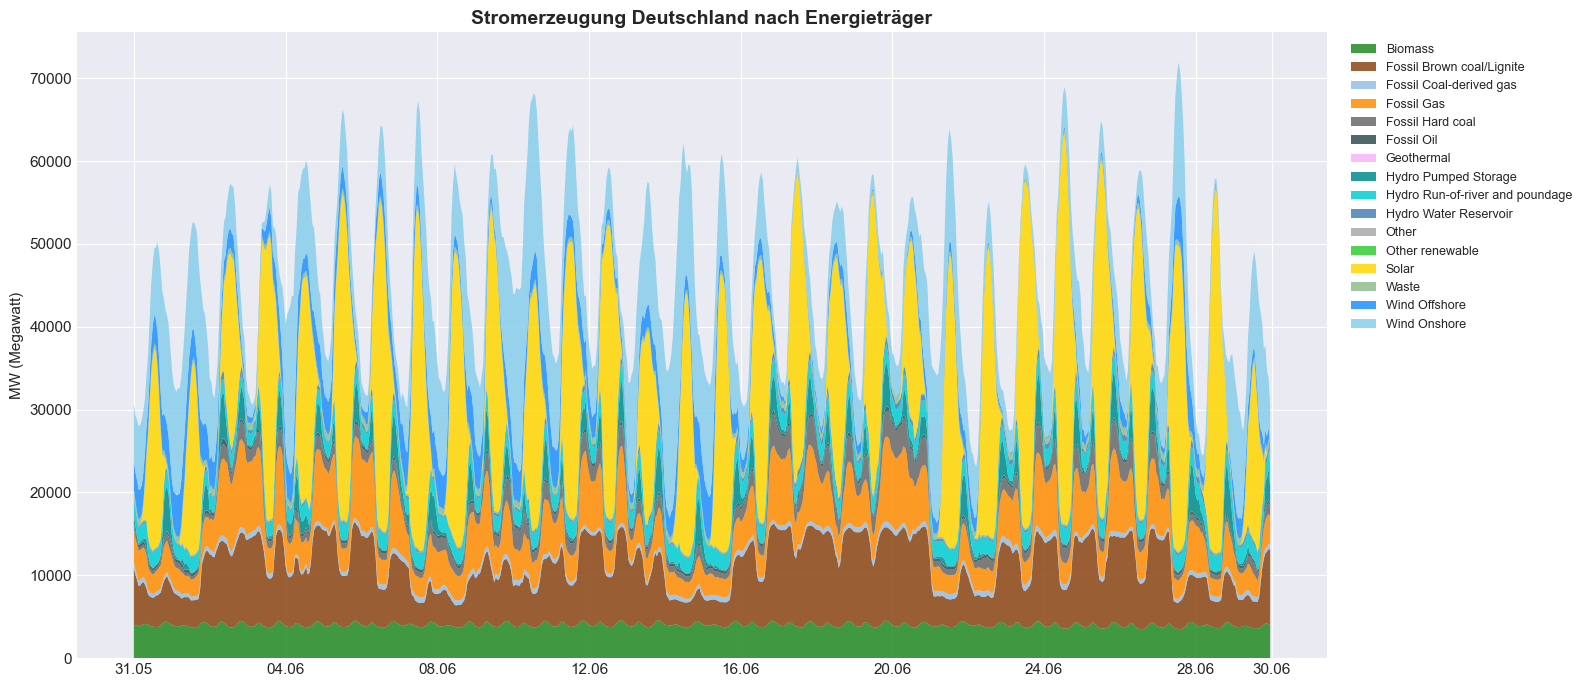

In [22]:
# Nur 'Actual Aggregated' Spalten behalten (nicht 'Actual Consumption')
# Das DataFrame hat MultiIndex-Spalten bei manchen Energieträgern
if isinstance(erzeugung.columns, pd.MultiIndex):
    # Nur die Actual Aggregated Werte
    erzeugung_agg = erzeugung.xs('Actual Aggregated', axis=1, level=1, drop_level=True)
else:
    erzeugung_agg = erzeugung.copy()

# NaN entfernen, Mittelwerte berechnen
erzeugung_agg = erzeugung_agg.fillna(0)

# Resample auf Stundenbasis
erzeugung_h = erzeugung_agg.resample('1h').mean()

# Stacked Area Chart
fig, ax = plt.subplots(figsize=(16, 7))

# Farben nach Energieträger
farben = {
    'Solar': '#FFD700', 'Wind Onshore': '#87CEEB', 'Wind Offshore': '#1E90FF',
    'Hydro Run-of-river and poundage': '#00CED1',
    'Hydro Pumped Storage': '#008B8B',
    'Natural Gas': '#FF8C00', 'Lignite': '#8B4513', 'Hard Coal': '#696969',
    'Nuclear': '#9400D3', 'Biomass': '#228B22', 'Other renewable': '#32CD32',
    'Other': '#A9A9A9', 'Waste': '#8FBC8F',
    'Hydro Water Reservoir': '#4682B4',
    'Fossil Gas': '#FF8C00', 'Fossil Brown coal/Lignite': '#8B4513',
    'Fossil Hard coal': '#696969', 'Fossil Oil': '#2F4F4F',
    'Wind Offshore': '#1E90FF', 'Wind Onshore': '#87CEEB',
}

cols = [c for c in erzeugung_h.columns if erzeugung_h[c].sum() > 0]
farb_liste = [farben.get(c, f'#{abs(hash(c)) % 0xFFFFFF:06X}') for c in cols]

ax.stackplot(erzeugung_h.index, 
             [erzeugung_h[c] for c in cols],
             labels=cols, colors=farb_liste, alpha=0.85)

ax.set_title('Stromerzeugung Deutschland nach Energieträger', fontsize=14, fontweight='bold')
ax.set_ylabel('MW (Megawatt)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9)
plt.tight_layout()
plt.savefig('erzeugung_stacked.png', dpi=150, bbox_inches='tight')
plt.show()

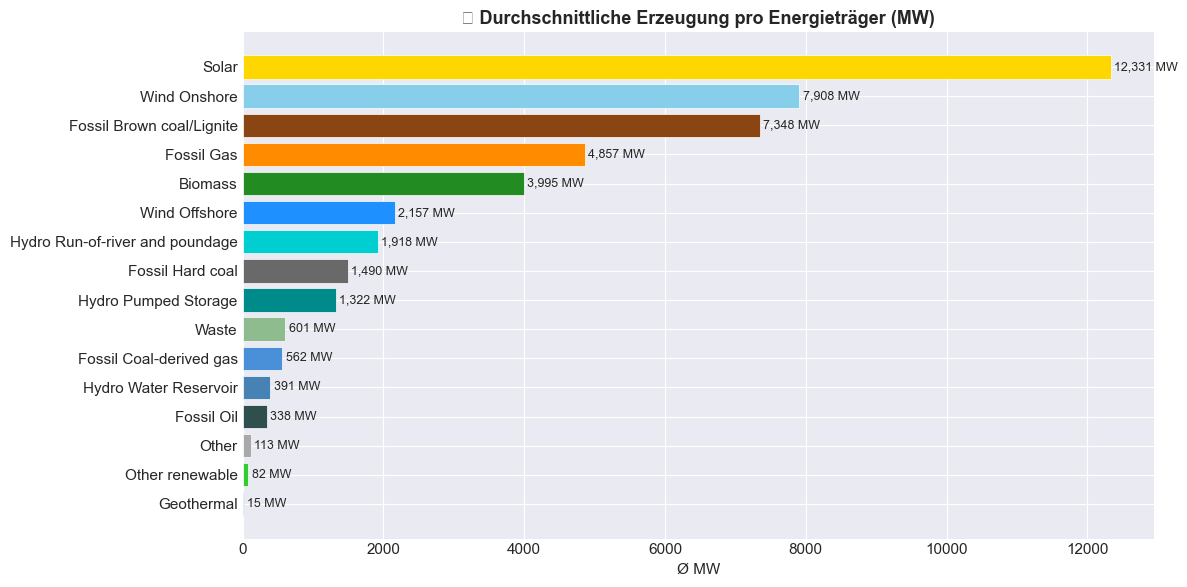

In [23]:
# Durchschnittliche Erzeugung als Balkendiagramm (Ranking)
mittelwerte = erzeugung_h.mean().sort_values(ascending=True)
mittelwerte = mittelwerte[mittelwerte > 0]

fig, ax = plt.subplots(figsize=(12, 6))
farb_liste2 = [farben.get(c, '#4A90D9') for c in mittelwerte.index]
bars = ax.barh(mittelwerte.index, mittelwerte.values, color=farb_liste2, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, mittelwerte.values):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f} MW', va='center', fontsize=9)

ax.set_title('⚡ Durchschnittliche Erzeugung pro Energieträger (MW)', fontsize=13, fontweight='bold')
ax.set_xlabel('Ø MW')
plt.tight_layout()
plt.savefig('erzeugung_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3: Preis vs. Erzeugung (Korrelationsanalyse)

Eine der spannendsten Analysen: **Wie hängen Strompreise und Erzeugung zusammen?**
- Mehr Erneuerbare → tendentiell niedrigere Preise (Merit-Order-Effekt)
- Hohe Nachfrage → höhere Preise

In [24]:
# Daten zusammenführen (auf gemeinsamen Zeitindex)
df_analyse = pd.DataFrame({
    'Preis_EUR_MWh': preise
})

# Wichtige Spalten extrahieren (falls vorhanden)
erneuerbare_cols = ['Solar', 'Wind Onshore', 'Wind Offshore']
fossile_cols = ['Natural Gas', 'Fossil Gas', 'Lignite', 'Fossil Brown coal/Lignite', 
                'Hard Coal', 'Fossil Hard coal']

# Erneuerbare summieren
vorhandene_ern = [c for c in erneuerbare_cols if c in erzeugung_h.columns]
vorhandene_fos = [c for c in fossile_cols if c in erzeugung_h.columns]

if vorhandene_ern:
    df_analyse['Erneuerbare_MW'] = erzeugung_h[vorhandene_ern].sum(axis=1).reindex(df_analyse.index, method='nearest')
if vorhandene_fos:
    df_analyse['Fossile_MW'] = erzeugung_h[vorhandene_fos].sum(axis=1).reindex(df_analyse.index, method='nearest')

df_analyse['Gesamt_MW'] = erzeugung_h.sum(axis=1).reindex(df_analyse.index, method='nearest')

df_analyse = df_analyse.dropna()
print('Analysedataset:')
print(df_analyse.head())
print(f'\n {len(df_analyse)} Datenpunkte')

Analysedataset:
                           Preis_EUR_MWh  Erneuerbare_MW  Fossile_MW  \
2024-06-01 00:00:00+02:00          88.58      10295.3600  11196.0600   
2024-06-01 01:00:00+02:00          88.82      10299.4925  10222.5100   
2024-06-01 02:00:00+02:00          79.66      11111.6175   9626.3575   
2024-06-01 03:00:00+02:00          72.14      11290.0500   8850.6475   
2024-06-01 04:00:00+02:00          71.87      11183.4125   8792.0925   

                            Gesamt_MW  
2024-06-01 00:00:00+02:00  30726.8825  
2024-06-01 01:00:00+02:00  29257.4350  
2024-06-01 02:00:00+02:00  28741.0625  
2024-06-01 03:00:00+02:00  28003.7600  
2024-06-01 04:00:00+02:00  28101.7875  

 721 Datenpunkte


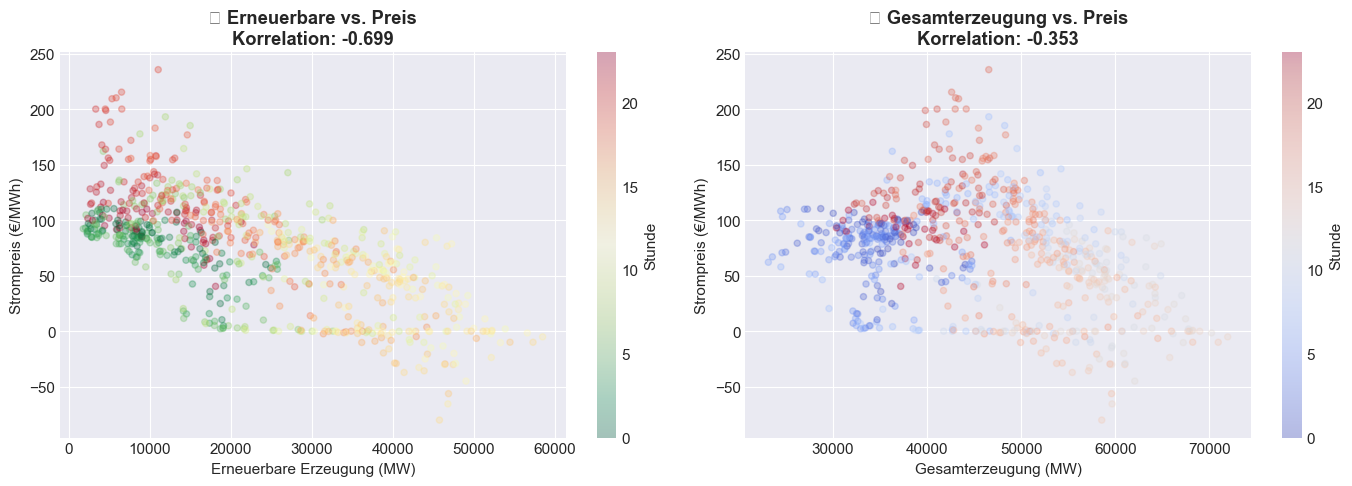

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Erneuerbare vs. Preis
if 'Erneuerbare_MW' in df_analyse.columns:
    sc1 = axes[0].scatter(df_analyse['Erneuerbare_MW'], df_analyse['Preis_EUR_MWh'],
                          alpha=0.3, c=df_analyse.index.hour, cmap='RdYlGn_r', s=20)
    plt.colorbar(sc1, ax=axes[0], label='Stunde')
    corr1 = df_analyse[['Erneuerbare_MW', 'Preis_EUR_MWh']].corr().iloc[0,1]
    axes[0].set_xlabel('Erneuerbare Erzeugung (MW)')
    axes[0].set_ylabel('Strompreis (€/MWh)')
    axes[0].set_title(f'🌿 Erneuerbare vs. Preis\nKorrelation: {corr1:.3f}', fontweight='bold')

# Plot 2: Gesamterzeugung vs. Preis
sc2 = axes[1].scatter(df_analyse['Gesamt_MW'], df_analyse['Preis_EUR_MWh'],
                      alpha=0.3, c=df_analyse.index.hour, cmap='coolwarm', s=20)
plt.colorbar(sc2, ax=axes[1], label='Stunde')
corr2 = df_analyse[['Gesamt_MW', 'Preis_EUR_MWh']].corr().iloc[0,1]
axes[1].set_xlabel('Gesamterzeugung (MW)')
axes[1].set_ylabel('Strompreis (€/MWh)')
axes[1].set_title(f'⚡ Gesamterzeugung vs. Preis\nKorrelation: {corr2:.3f}', fontweight='bold')

plt.tight_layout()
plt.savefig('korrelation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4: Stromlast (Verbrauch) & Lastprognose

**Was ist das?**  
`query_load()` gibt die **tatsächliche Netzlast** zurück (wie viel Strom in Deutschland gerade verbraucht wird).  
`query_load_forecast()` gibt die **Prognose** zurück, die Netzbetreiber im Voraus erstellen.

In [26]:
# Tatsächliche Last
last = client.query_load(LAND, start=start, end=end)

# Lastprognose
last_prognose = client.query_load_forecast(LAND, start=start, end=end)

print('Tatsächliche Last:')
print(last.head())
print('\nLastprognose:')
print(last_prognose.head())

Tatsächliche Last:
                           Actual Load
2024-06-01 00:00:00+02:00     41858.07
2024-06-01 00:15:00+02:00     41590.99
2024-06-01 00:30:00+02:00     41074.47
2024-06-01 00:45:00+02:00     40482.82
2024-06-01 01:00:00+02:00     39658.87

Lastprognose:
                           Forecasted Load
2024-06-01 00:00:00+02:00         43671.36
2024-06-01 00:15:00+02:00         43016.54
2024-06-01 00:30:00+02:00         42657.71
2024-06-01 00:45:00+02:00         42174.72
2024-06-01 01:00:00+02:00         41295.49


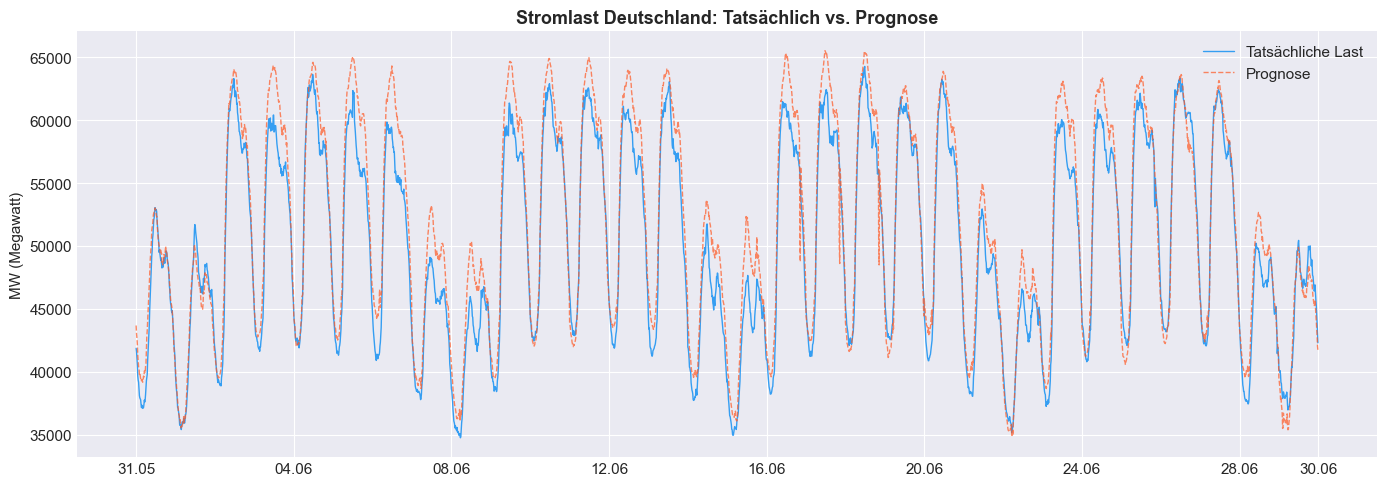

 Mittlerer absoluter Prognosefehler (MAE): 1,750 MW


In [30]:
# Zusammenführen und vergleichen
if isinstance(last, pd.DataFrame):
    last_series = last.iloc[:, 0]
else:
    last_series = last

if isinstance(last_prognose, pd.DataFrame):
    prognose_series = last_prognose.iloc[:, 0]
else:
    prognose_series = last_prognose

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(last_series.index, last_series.values, label='Tatsächliche Last', 
        color='#2196F3', linewidth=1, alpha=0.9)
ax.plot(prognose_series.index, prognose_series.values, label='Prognose',
        color='#FF5722', linestyle='--', linewidth=1, alpha=0.7)

ax.set_title('Stromlast Deutschland: Tatsächlich vs. Prognose', fontsize=13, fontweight='bold')
ax.set_ylabel('MW (Megawatt)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))

plt.tight_layout()
plt.savefig('last_vs_prognose.png', dpi=150, bbox_inches='tight')
plt.show()

# Prognosegenauigkeit
gemeinsam = pd.concat([last_series.rename('Ist'), prognose_series.rename('Prognose')], axis=1).dropna()
mae = (gemeinsam['Ist'] - gemeinsam['Prognose']).abs().mean()
print(f' Mittlerer absoluter Prognosefehler (MAE): {mae:,.0f} MW')

---
## 5: Wind & Solar Prognose

Netzbetreiber veröffentlichen täglich Prognosen für Wind- und Solareinspeisung. Diese sind wichtig für die Netzplanung.

In [28]:
# Wind & Solar Prognose
wind_solar = client.query_wind_and_solar_forecast(LAND, start=start, end=end)

print('Wind & Solar Prognose:')
print(wind_solar.head())
print('\nSpalten:', wind_solar.columns.tolist())

Wind & Solar Prognose:
                           Solar  Wind Offshore  Wind Onshore
2024-06-01 00:00:00+02:00    0.0        3556.14       7923.04
2024-06-01 00:15:00+02:00    0.0        3559.30       7902.84
2024-06-01 00:30:00+02:00    0.0        3558.50       7881.96
2024-06-01 00:45:00+02:00    0.0        3562.74       7863.58
2024-06-01 01:00:00+02:00    0.0        3582.32       7838.66

Spalten: ['Solar', 'Wind Offshore', 'Wind Onshore']


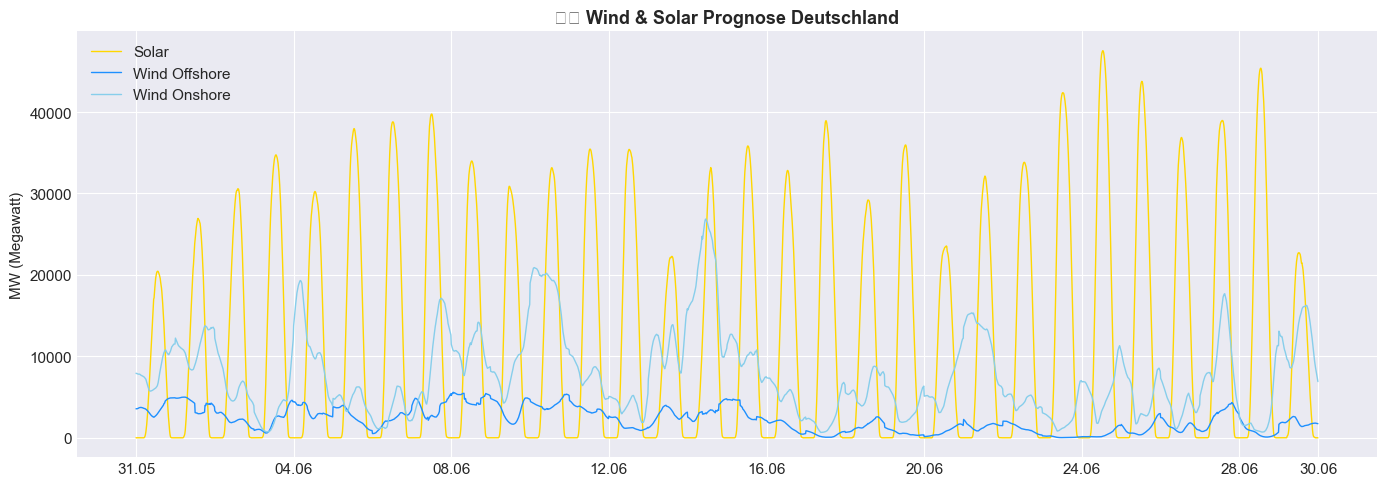

In [31]:
fig, ax = plt.subplots(figsize=(14, 5))

farben_ws = {'Solar': '#FFD700', 'Wind Onshore': '#87CEEB', 'Wind Offshore': '#1E90FF'}

for col in wind_solar.columns:
    col_name = col if isinstance(col, str) else str(col)
    farbe = next((v for k, v in farben_ws.items() if k.lower() in col_name.lower()), '#888888')
    ax.plot(wind_solar.index, wind_solar[col], label=col_name, color=farbe, linewidth=1)

ax.set_title('🌤️ Wind & Solar Prognose Deutschland', fontsize=13, fontweight='bold')
ax.set_ylabel('MW (Megawatt)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))

plt.tight_layout()
plt.savefig('wind_solar.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6: Grenzüberschreitende Stromflüsse

Deutschland ist stark vernetzt. Diese Abfrage zeigt, wie viel Strom **zwischen Ländern fließt** (positive Werte = Export, negative = Import).

In [32]:
# Cross-Border Flows: Deutschland → Nachbarn
nachbarn = [
    ('DE_LU', 'FR', 'DE → Frankreich'),
    ('DE_LU', 'AT', 'DE → Österreich'),
    ('DE_LU', 'NL', 'DE → Niederlande'),
    ('DE_LU', 'PL', 'DE → Polen'),
]

flows = {}
for von, nach, name in nachbarn:
    try:
        flow = client.query_crossborder_flows(von, nach, start=start, end=end)
        flows[name] = flow
        print(f'{name}: Ø {flow.mean():,.0f} MW')
    except Exception as e:
        print(f'{name}: Fehler - {e}')

DE → Frankreich: Ø 46 MW
DE → Österreich: Ø 630 MW
DE → Niederlande: Ø 498 MW
DE → Polen: Ø 1,123 MW


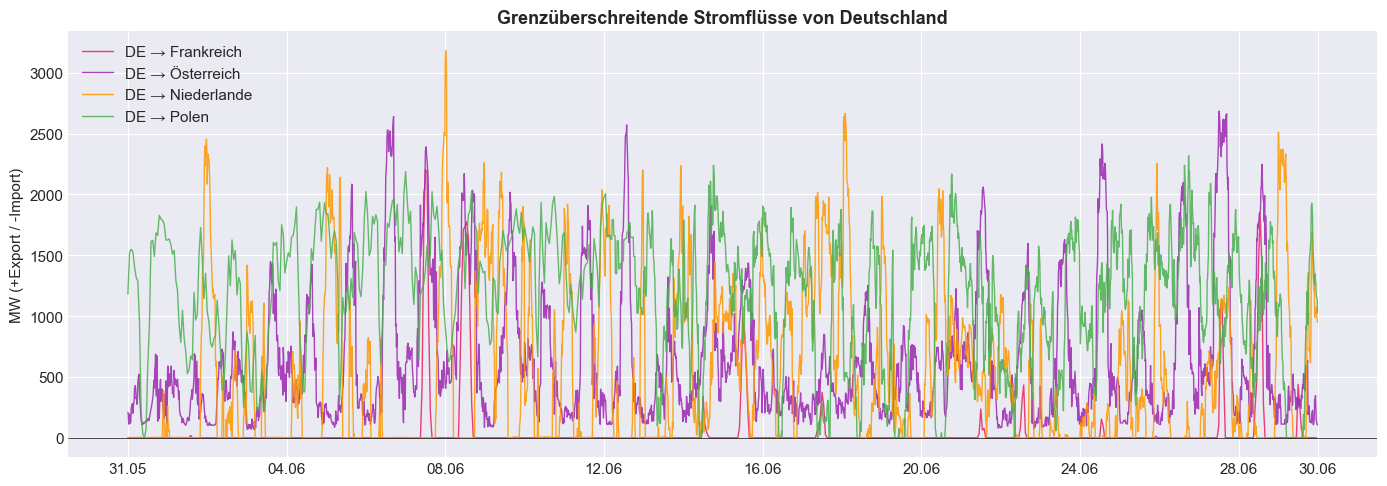

In [34]:
if flows:
    fig, ax = plt.subplots(figsize=(14, 5))
    
    flow_farben = ['#E91E63', '#9C27B0', '#FF9800', '#4CAF50']
    for (name, series), farbe in zip(flows.items(), flow_farben):
        ax.plot(series.index, series.values, label=name, linewidth=1, color=farbe, alpha=0.85)
    
    ax.axhline(0, color='black', linestyle='-', linewidth=0.5)
    ax.fill_between(list(flows.values())[0].index, 0, alpha=0.05, color='blue')
    ax.set_title('Grenzüberschreitende Stromflüsse von Deutschland', fontsize=13, fontweight='bold')
    ax.set_ylabel('MW (+Export / -Import)')
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
    
    plt.tight_layout()
    plt.savefig('crossborder.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 7: Installierte Kapazitäten

Wie viel **installierte Leistung** (in MW) hat Deutschland in den verschiedenen Energieträgern? Das ist die maximale theoretische Erzeugungskapazität.

In [35]:
# Installierte Kapazitäten
kapazitaet = client.query_installed_generation_capacity(LAND, start=start, end=end)

print('Installierte Kapazitäten:')
print(kapazitaet.head())

Installierte Kapazitäten:
                           Biomass  Fossil Brown coal/Lignite  \
2024-01-02 00:00:00+01:00  8659.54                    18365.0   

                           Fossil Coal-derived gas  Fossil Gas  \
2024-01-02 00:00:00+01:00                   1257.0     36327.0   

                           Fossil Hard coal  Fossil Oil  Fossil Oil shale  \
2024-01-02 00:00:00+01:00           18411.0      4118.0               0.0   

                           Fossil Peat  Geothermal  Hydro Pumped Storage  \
2024-01-02 00:00:00+01:00          0.0        54.0                9449.0   

                           Hydro Run-of-river and poundage  \
2024-01-02 00:00:00+01:00                           3752.8   

                           Hydro Water Reservoir  Marine   Other  \
2024-01-02 00:00:00+01:00                 1392.0     0.0  1630.0   

                           Other renewable     Solar   Waste  Wind Offshore  \
2024-01-02 00:00:00+01:00           356.45  77015.56  1832.0 

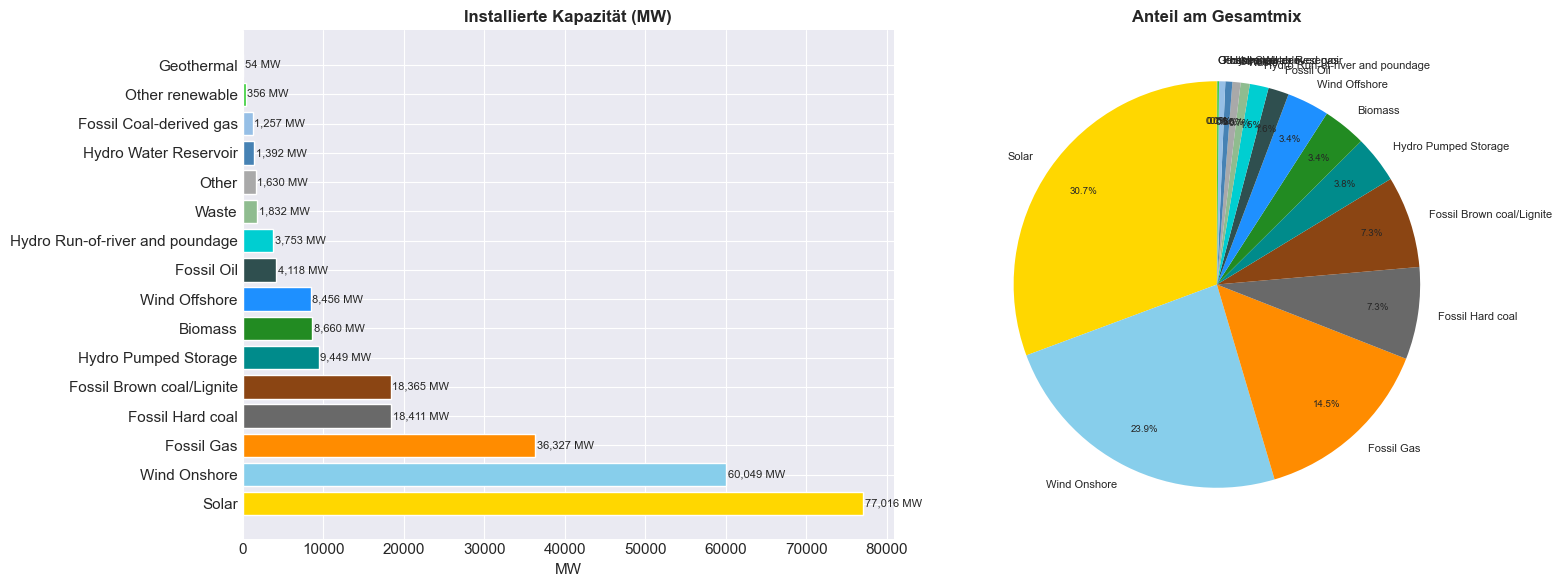

In [36]:
# Letzter verfügbarer Datenpunkt
kap_aktuell = kapazitaet.iloc[-1].sort_values(ascending=False)
kap_aktuell = kap_aktuell[kap_aktuell > 0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Balkendiagramm
kap_farben = [farben.get(str(c), f'#{abs(hash(str(c))) % 0xFFFFFF:06X}') for c in kap_aktuell.index]
bars = ax1.barh([str(c) for c in kap_aktuell.index], kap_aktuell.values, 
                color=kap_farben, edgecolor='white')

for bar, val in zip(bars, kap_aktuell.values):
    ax1.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
             f'{val:,.0f} MW', va='center', fontsize=8)

ax1.set_title('Installierte Kapazität (MW)', fontsize=12, fontweight='bold')
ax1.set_xlabel('MW')

# Kreisdiagramm
wedges, texts, autotexts = ax2.pie(
    kap_aktuell.values,
    labels=[str(c) for c in kap_aktuell.index],
    colors=kap_farben,
    autopct='%1.1f%%',
    pctdistance=0.8,
    startangle=90
)
for text in texts: text.set_fontsize(8)
for autotext in autotexts: autotext.set_fontsize(7)

ax2.set_title('Anteil am Gesamtmix', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('kapazitaeten.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8: Vollständige Übersicht aller Methoden

Hier findest du alle verfügbaren Abfragen der Bibliothek mit kurzer Erklärung:

In [38]:
methoden = {
    'PREISE & MARKT': {
        'query_day_ahead_prices': ('Series', 'Day-Ahead-Strompreise in €/MWh'),
        'query_imbalance_prices': ('DataFrame', 'Regelenergie-Ungleichgewichtspreise'),
        'query_activated_balancing_energy_prices': ('DataFrame', 'Aktivierte Regelenergie-Preise'),
        'query_contracted_reserve_prices': ('DataFrame', 'Kontrahierte Regelleistungspreise'),
        'query_offered_capacity': ('Series', 'Angebotene Kapazität'),
        'query_net_position': ('Series', 'Netto-Position im Markt'),
    },
    'LAST (VERBRAUCH)': {
        'query_load': ('DataFrame', 'Tatsächliche Netzlast in MW'),
        'query_load_forecast': ('DataFrame', 'Lastprognose für den nächsten Tag'),
        'query_load_and_forecast': ('DataFrame', 'Ist-Last und Prognose kombiniert'),
    },
    'ERZEUGUNG': {
        'query_generation': ('DataFrame', 'Tatsächliche Erzeugung je Energieträger in MW'),
        'query_generation_per_plant': ('DataFrame', 'Erzeugung je einzelnem Kraftwerk'),
        'query_generation_forecast': ('DataFrame', 'Erzeugungsprognose'),
        'query_wind_and_solar_forecast': ('DataFrame', 'Wind & Solar Prognose'),
        'query_intraday_wind_and_solar_forecast': ('DataFrame', 'Intraday Wind & Solar Prognose'),
        'query_installed_generation_capacity': ('DataFrame', 'Installierte Kapazität je Energieträger'),
        'query_installed_generation_capacity_per_unit': ('DataFrame', 'Installierte Kapazität je Anlage'),
        'query_aggregate_water_reservoirs_and_hydro_storage': ('Series', 'Wasserspeicherstand Hydro'),
    },
    'GRENZÜBERGREIFEND': {
        'query_crossborder_flows': ('Series', 'Physikalische Cross-Border Flüsse in MW'),
        'query_scheduled_exchanges': ('Series', 'Geplante Stromaustausche'),
        'query_net_transfer_capacity_dayahead': ('Series', 'Netto-Transferkapazität (Day-Ahead)'),
        'query_net_transfer_capacity_weekahead': ('Series', 'NTC Wochenvorausschau'),
        'query_net_transfer_capacity_monthahead': ('Series', 'NTC Monatsvorausschau'),
        'query_physical_crossborder_allborders': ('DataFrame', 'Physikalische Flüsse alle Grenzen'),
        'query_import': ('DataFrame', 'Importflüsse'),
    },
    'REGELENERGIE & BALANCE': {
        'query_imbalance_volumes': ('DataFrame', 'Ungleichgewichtsvolumen'),
        'query_activated_balancing_energy': ('DataFrame', 'Aktivierte Regelenergie'),
        'query_contracted_reserve_amount': ('DataFrame', 'Kontrahierte Regelleistungsmengen'),
        'query_procured_balancing_capacity': ('DataFrame', 'Beschaffte Regelkapazität'),
        'query_aggregated_bids': ('Series', 'Aggregierte Gebote'),
    },
    'VERFÜGBARKEIT': {
        'query_unavailability_of_generation_units': ('DataFrame', 'Kraftwerksausfälle/-abschaltungen'),
        'query_unavailability_of_production_units': ('DataFrame', 'Produktionseinheiten-Ausfälle'),
        'query_unavailability_transmission': ('DataFrame', 'Übertragungsnetz-Ausfälle'),
        'query_unavailability_of_offshore_grid': ('DataFrame', 'Offshore-Netz Ausfälle'),
        'query_withdrawn_unavailability_of_generation_units': ('DataFrame', 'Zurückgezogene Verfügbarkeitsmeldungen'),
    },
}

# Schöne Ausgabe
for kategorie, methoden_dict in methoden.items():

    print(f'   {kategorie}')
   
    for methode, (rückgabe, beschreibung) in methoden_dict.items():
        print(f'  client.{methode}()')
        print(f'    → Rückgabe: {rückgabe:<12}  {beschreibung}')

   PREISE & MARKT
  client.query_day_ahead_prices()
    → Rückgabe: Series        Day-Ahead-Strompreise in €/MWh
  client.query_imbalance_prices()
    → Rückgabe: DataFrame     Regelenergie-Ungleichgewichtspreise
  client.query_activated_balancing_energy_prices()
    → Rückgabe: DataFrame     Aktivierte Regelenergie-Preise
  client.query_contracted_reserve_prices()
    → Rückgabe: DataFrame     Kontrahierte Regelleistungspreise
  client.query_offered_capacity()
    → Rückgabe: Series        Angebotene Kapazität
  client.query_net_position()
    → Rückgabe: Series        Netto-Position im Markt
   LAST (VERBRAUCH)
  client.query_load()
    → Rückgabe: DataFrame     Tatsächliche Netzlast in MW
  client.query_load_forecast()
    → Rückgabe: DataFrame     Lastprognose für den nächsten Tag
  client.query_load_and_forecast()
    → Rückgabe: DataFrame     Ist-Last und Prognose kombiniert
   ERZEUGUNG
  client.query_generation()
    → Rückgabe: DataFrame     Tatsächliche Erzeugung je Energietr

---
## 9: Daten speichern

Alle Pandas-Objekte können einfach exportiert werden:

In [ ]:
# CSV Export
preise.to_csv('strompreise_DE_LU.csv', index=True)
erzeugung_h.to_csv('erzeugung_DE_LU.csv', index=True)

# Excel Export (alle Daten in einem File)
with pd.ExcelWriter('entsoe_deutschland.xlsx', engine='openpyxl') as writer:
    preise.to_excel(writer, sheet_name='Day-Ahead-Preise')
    erzeugung_h.to_excel(writer, sheet_name='Erzeugung')
    if 'last_series' in dir():
        last_series.to_excel(writer, sheet_name='Netzlast')

print('✅ Daten exportiert: strompreise_DE_LU.csv, erzeugung_DE_LU.csv, entsoe_deutschland.xlsx')

---
## 10: RawClient — Rohdaten (XML)

Für Debugging oder wenn du direkt mit der API arbeiten willst:

In [39]:
# EntsoeRawClient gibt rohe XML-Strings zurück
raw_client = EntsoeRawClient(api_key=API_KEY)

xml_data = raw_client.query_day_ahead_prices(LAND, start, end)
print(' Rohe XML-Antwort (Anfang):')
print(xml_data[:1500])  # Erste 1500 Zeichen

# Als Datei speichern
with open('preise_raw.xml', 'w') as f:
    f.write(xml_data)
print('\n XML gespeichert als preise_raw.xml')

 Rohe XML-Antwort (Anfang):
<?xml version="1.0" encoding="utf-8"?>
  <Publication_MarketDocument xmlns="urn:iec62325.351:tc57wg16:451-3:publicationdocument:7:3">
    <mRID>5d71d668d207424d954f77dfc2735721</mRID>
    <revisionNumber>1</revisionNumber>
    <type>A44</type>
    <sender_MarketParticipant.mRID codingScheme="A01">10X1001A1001A450</sender_MarketParticipant.mRID>
    <sender_MarketParticipant.marketRole.type>A32</sender_MarketParticipant.marketRole.type>
    <receiver_MarketParticipant.mRID codingScheme="A01">10X1001A1001A450</receiver_MarketParticipant.mRID>
    <receiver_MarketParticipant.marketRole.type>A33</receiver_MarketParticipant.marketRole.type>
    <createdDateTime>2026-04-28T14:19:17Z</createdDateTime>
    <period.timeInterval>
      <start>2024-05-31T22:00Z</start>
      <end>2024-06-30T22:00Z</end>
    </period.timeInterval>
      <TimeSeries>
        <mRID>1</mRID>
        <auction.type>A01</auction.type>
        <businessType>A62</businessType>
        <in_Domai